# Customer Churn Prediction
### End-to-End Machine Learning Project

**Objective:** Predict which telecom customers are likely to churn (cancel their subscription), identify the key drivers of churn, and recommend retention actions.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features) — a widely used, realistic proxy for subscription-business churn problems.

**Structure:**
1. Business Problem & Approach
2. Data Loading & Inspection
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering
6. Train/Test Split & Handling Class Imbalance
7. Model Building (Logistic Regression, Random Forest, XGBoost)
8. Model Evaluation & Comparison
9. Feature Importance & Business Insights
10. Recommendations
11. Saving the Final Model


## 1. Business Problem & Approach

Customer churn directly hits recurring revenue. Acquiring a new customer typically costs far more than retaining an existing one, so a model that flags **who is likely to churn, and why**, lets the business intervene early (discounts, better plans, proactive support) with the *right* customers instead of blanket campaigns.

**Framing this as a case, the way ZS would expect:**
- **Business question:** Which customers are at risk, and what actionable levers reduce that risk?
- **ML framing:** Binary classification (`Churn`: Yes/No), optimizing for **recall on churners** (missing a churner is costlier than a false alarm) while keeping precision usable for a retention team with limited outreach capacity.
- **Success metric:** ROC-AUC for ranking risk, plus recall/precision trade-off via the confusion matrix — not just accuracy, since churn is imbalanced (~27% churn rate).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, f1_score)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv('telco_churn.csv')
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observations:**
- `TotalCharges` is read as an object (string) but should be numeric — likely has blank strings for new customers with 0 tenure.
- `customerID` is an identifier, not a predictive feature — will be dropped.
- Target column `Churn` is Yes/No — needs binary encoding.


## 3. Exploratory Data Analysis

In [4]:
# Fix TotalCharges: coerce to numeric, inspect resulting NaNs
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges: {df['TotalCharges'].isna().sum()}")
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]


Missing TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


These are all customers with `tenure = 0` (brand new customers) — TotalCharges is legitimately unset. We'll fill these with 0.

In [5]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.isnull().sum().sum()  # confirm no more missing values


np.int64(0)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


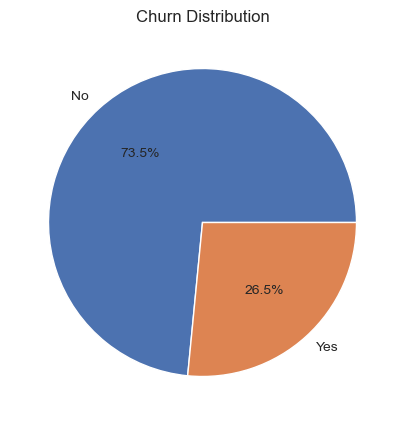

In [6]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

plt.figure(figsize=(5,5))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()


~27% churn rate — a meaningful class imbalance we'll need to handle before modeling (SMOTE, or class weighting).

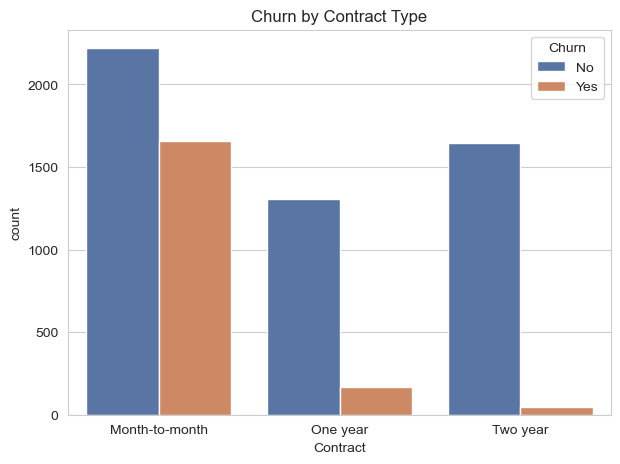

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

In [7]:
# Churn rate by contract type -- typically one of the strongest churn drivers
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#4C72B0','#DD8452'])
plt.title('Churn by Contract Type')
plt.show()

df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(1)


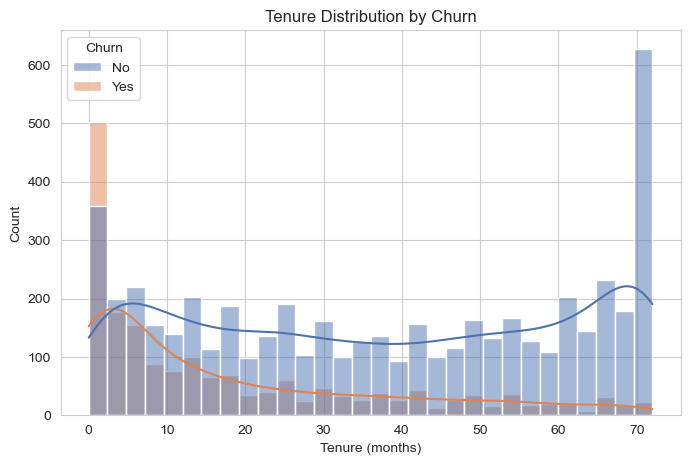

In [8]:
# Tenure distribution by churn
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette=['#4C72B0','#DD8452'])
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()


Churn is heavily concentrated in the first few months — a classic 'early-life churn' pattern. This is a strong signal for onboarding-focused retention.

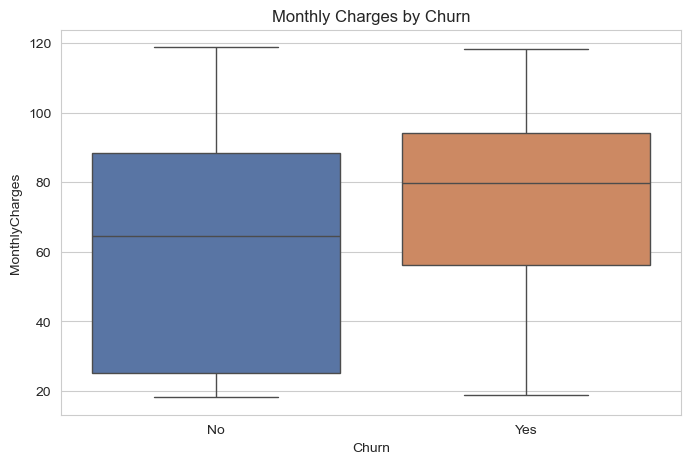

In [9]:
# Monthly charges by churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#4C72B0','#DD8452'])
plt.title('Monthly Charges by Churn')
plt.show()


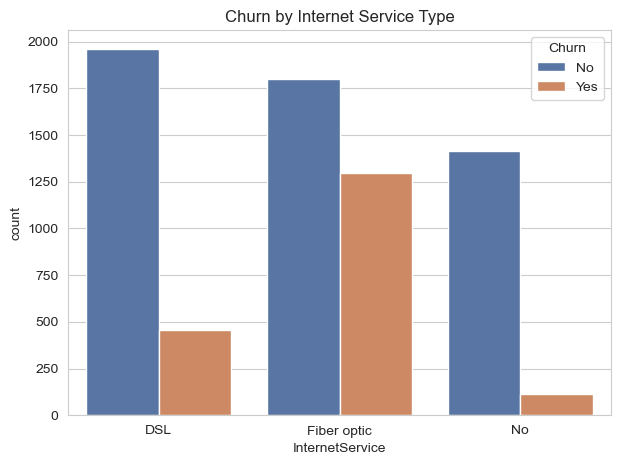

InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64

In [10]:
# Internet service type vs churn
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#4C72B0','#DD8452'])
plt.title('Churn by Internet Service Type')
plt.show()

df.groupby('InternetService')['Churn'].apply(lambda x: (x=='Yes').mean()*100).round(1)


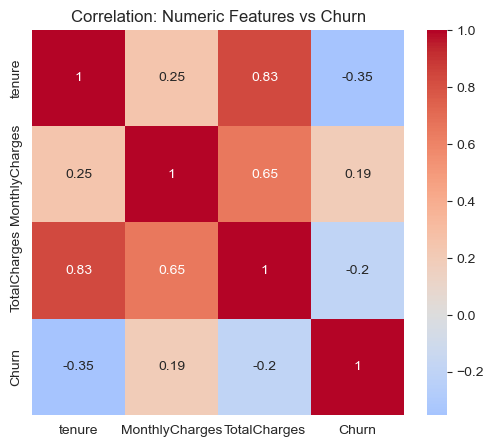

In [11]:
# Correlation heatmap for numeric features (after quick encoding of target)
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)
plt.figure(figsize=(6,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Numeric Features vs Churn')
plt.show()


## 4. Data Cleaning & Preprocessing

Steps:
1. Drop `customerID` (identifier, not predictive)
2. Encode target `Churn` → 1/0
3. Encode binary categorical columns (Yes/No, Male/Female) via label encoding
4. One-hot encode multi-category categorical columns
5. Scale numeric columns for the logistic regression model


In [12]:
data = df.drop('customerID', axis=1).copy()
data['Churn'] = (data['Churn'] == 'Yes').astype(int)

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    data[col] = le.fit_transform(data[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=multi_cat_cols, drop_first=True)

print(data.shape)
data.head()


(7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## 5. Feature Engineering

A couple of derived features that often help churn models:
- **AvgMonthlySpend** = TotalCharges / (tenure + 1) — smooths out billing irregularities
- **TenureGroup** — bucketed tenure, since the relationship with churn is non-linear (steep drop-off early, then flattens)


In [13]:
data['AvgMonthlySpend'] = data['TotalCharges'] / (data['tenure'] + 1)

data['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 60, 72],
                              labels=['0-1yr', '1-2yr', '2-4yr', '4-5yr', '5-6yr'], include_lowest=True)
data = pd.get_dummies(data, columns=['TenureGroup'], drop_first=True)

print(data.shape)


(7043, 36)


## 6. Train/Test Split & Class Imbalance

In [14]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}, Test churn rate: {y_test.mean():.2%}")


Train: (5634, 35), Test: (1409, 35)
Train churn rate: 26.54%, Test churn rate: 26.54%


In [15]:
# SMOTE to balance the training set only (never touch the test set)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


## 7. Model Building

Three models, increasing in complexity, so we can compare interpretability vs. performance:
1. **Logistic Regression** — fast, interpretable baseline, coefficients are directly explainable to stakeholders
2. **Random Forest** — captures non-linear interactions, gives feature importances
3. **XGBoost** — typically the strongest performer on tabular data like this


In [16]:
results = {}

# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
results['Logistic Regression'] = {'model': lr, 'pred': lr_pred, 'proba': lr_proba}


In [17]:
# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE,
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)  # tree models don't need scaling
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {'model': rf, 'pred': rf_pred, 'proba': rf_proba}


In [18]:
# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                     scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                     eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
results['XGBoost'] = {'model': xgb, 'pred': xgb_pred, 'proba': xgb_proba}


## 8. Model Evaluation & Comparison

In [19]:
summary = []
for name, r in results.items():
    auc = roc_auc_score(y_test, r['proba'])
    f1 = f1_score(y_test, r['pred'])
    report = classification_report(y_test, r['pred'], output_dict=True)
    summary.append({
        'Model': name,
        'ROC-AUC': round(auc, 3),
        'F1 (Churn)': round(f1, 3),
        'Precision (Churn)': round(report['1']['precision'], 3),
        'Recall (Churn)': round(report['1']['recall'], 3),
        'Accuracy': round(report['accuracy'], 3),
    })

summary_df = pd.DataFrame(summary).sort_values('ROC-AUC', ascending=False)
summary_df


,Model,ROC-AUC,F1 (Churn),Precision (Churn),Recall (Churn),Accuracy
0,Logistic Regression,0.845,0.621,0.509,0.794,0.742
1,Random Forest,0.842,0.627,0.543,0.741,0.766
2,XGBoost,0.837,0.629,0.526,0.781,0.755


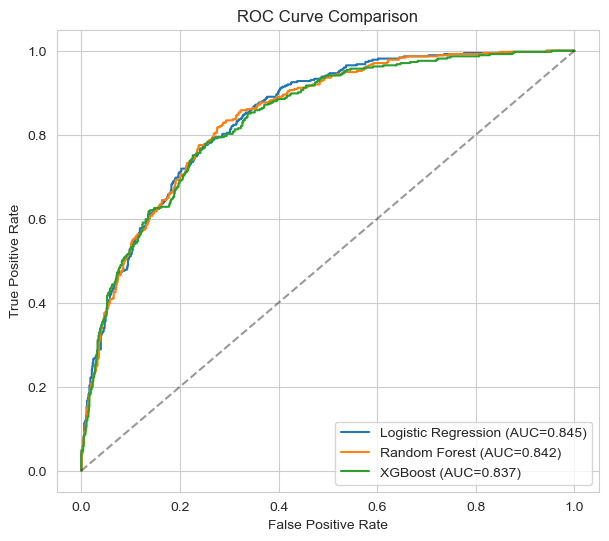

In [20]:
# ROC curves for all models
plt.figure(figsize=(7,6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    auc = roc_auc_score(y_test, r['proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


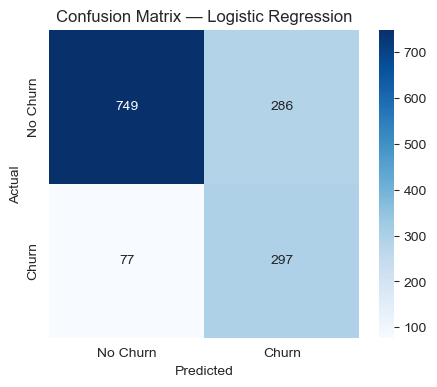

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [21]:
# Confusion matrix for the best model (by ROC-AUC)
best_name = summary_df.iloc[0]['Model']
best_pred = results[best_name]['pred']

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(classification_report(y_test, best_pred, target_names=['No Churn', 'Churn']))


## 9. Feature Importance & Business Insights

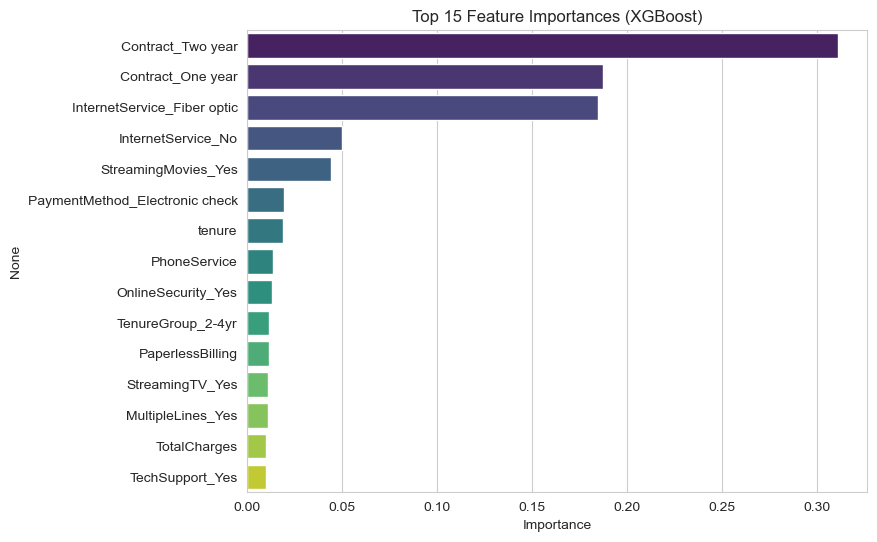

Contract_Two year                 0.311104
Contract_One year                 0.187401
InternetService_Fiber optic       0.184966
InternetService_No                0.049680
StreamingMovies_Yes               0.043927
PaymentMethod_Electronic check    0.019451
tenure                            0.018539
PhoneService                      0.013739
OnlineSecurity_Yes                0.013095
TenureGroup_2-4yr                 0.011538
PaperlessBilling                  0.011159
StreamingTV_Yes                   0.011092
MultipleLines_Yes                 0.010644
TotalCharges                      0.009969
TechSupport_Yes                   0.009883
dtype: float32

In [22]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

importances


## 10. Business Recommendations

Translating model findings into action :

1. **Target month-to-month customers with contract upgrade incentives** — a small discount for moving to a 1-year contract reduces churn risk far more than the discount costs, given the size of the effect.
2. **Fix the first-90-days experience** — since churn is concentrated in early tenure, build a proactive onboarding/check-in flow for new customers rather than waiting for them to file a complaint.
3. **Bundle in tech support / online security for at-risk segments** — customers without these add-ons churn more; offering a free trial of these services to high-risk customers could reduce churn.
4. **Score the customer base monthly** with this model and route the top-decile risk customers to a retention team for a proactive call/offer, rather than reacting only after a cancellation request.
5. **Recommended metric to track post-launch:** retention rate lift within the top-risk decile vs. a holdout control group — this proves causal impact, not just correlation.


## 11. Saving the Final Model

In [23]:
joblib.dump(xgb, 'churn_model_xgboost.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("Model, scaler, and feature list saved.")


Model, scaler, and feature list saved.


### How to use the saved model on new data
```python
model = joblib.load('churn_model_xgboost.pkl')
feature_columns = joblib.load('feature_columns.pkl')
# new_customer_df must be preprocessed identically (same encoding + engineered features),
# then reindexed to feature_columns before calling model.predict_proba(...)
```
